In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [3]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

Loaded environment variables from /Users/Akseldkw/Desktop/Columbia/COMS4776/.env.


INFO:datasets:JAX version 0.7.2 available.


In [4]:
from kret_studies.kret_torch.mixin.constants import DEVICE_TORCH_STR, DEVICE_LITERAL

device: DEVICE_LITERAL = DEVICE_TORCH_STR
NUM_EPOCHS = 50

In [5]:
from trainer import save_model_auto, load_model_auto, model_filename

In [ ]:
# !pip install thop
# !pip install tdqm

# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [7]:
def scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Computes scaled dot product attention with an optional mask.
      q : shape ( batch, k, hidden_size)
      k : shape ( batch, seq_len, hidden_size)
      v : shape ( batch, seq_len, hidden_size)
      mask: optional. shape (k, seq_len)

    returns:
        context   : shape (batch, k, hidden_size)
        attention : shape (batch, k, seq_len)
    """

    # ------------
    # FILL THIS IN
    # ------------
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [8]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor, annots: torch.Tensor):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        # q =
        # k =
        # v =
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [9]:
class CausalAttention(Attention):
    def __init__(self, hidden_size: int):
        super().__init__(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        # q =
        # k =
        # v =
        # mask =
        seq_len = x.size(1)
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.tril(torch.ones((seq_len, seq_len), device=x.device)).bool()
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [10]:
cros_attn = Attention(32)
caus_attn = CausalAttention(32)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32).to(device)
inp2 = torch.randn(4, 16, 32).to(device)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [11]:
class PositionalEncoding(nn.Module):
    pe: torch.Tensor

    def __init__(self, hidden_size: int, max_len: int = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0)

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, max_len=max_len)

    def forward(self, idx: int):
        return self.pe[idx]

In [12]:
class MLP(nn.Module):

    def __init__(self, hidden_size: int):
        super().__init__()
        self.layer1 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu = nn.ReLU()
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor, annotation: torch.Tensor):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [13]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_size: int, num_layers: int, dataset_name: str
    ):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights)  # initialize the weights to a small number
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size,
            num_layers=num_layers,
            vocab_size=vocab_size,
            dataset_name=dataset_name,
        )

    def forward(self, inputs: torch.Tensor, annots: torch.Tensor):

        pos_x = torch.arange(
            0, inputs.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(
            0, annots.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {"self_attn": self_attn, "cros_attn": cros_attn}

    def _init_weights(self, module: torch.nn.Module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [14]:
from dataset import EncoderDecoderDataset, DecoderDataset
from utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from trainer import train
import torch.optim as optim


data_path = str("./")  # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, "pig_latin_small")
encdec_ds_large = EncoderDecoderDataset(data_path, "pig_latin_large")

In [15]:
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

Dataset sample:
Input: <SOS>attacksway
Annotation: attacks
Target: attacksway<EOS>


In [16]:
# model = load_model_auto(
#     TransformerEncoderDecoder,
#     vocab_size=len(encdec_ds_small.idx_to_token),
#     hidden_size=16,
#     num_layers=4,
#     dataset_name="small",
# )
model = TransformerEncoderDecoder(
    vocab_size=len(encdec_ds_small.idx_to_token),
    hidden_size=16,
    num_layers=4,
    dataset_name="small",
)

In [17]:
optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 2.611418 | Val loss 2.372160


Epoch 2 | Train loss: 2.130110 | Val loss 1.988386


Epoch 3 | Train loss: 1.840955 | Val loss 1.654330


Epoch 4 | Train loss: 1.400597 | Val loss 1.170410


Epoch 5 | Train loss: 0.924962 | Val loss 0.772506


...

Epoch 47 | Train loss: 0.012742 | Val loss 0.106851


Epoch 48 | Train loss: 0.015495 | Val loss 0.120200


Epoch 49 | Train loss: 0.015922 | Val loss 0.115641


Epoch 50 | Train loss: 0.011851 | Val loss 0.118588


PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder/50_epochs/Model_ds_namesmall_vocab30_hid16_layers4.pt')

In [18]:
def encdec_generate(
    input: str,
    model: TransformerEncoderDecoder,
    dataset: EncoderDecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor(
        [dataset.to_idx(input) + [dataset.end_idx] * (max(0, 12 - len(input)))]
    ).to(device)
    # pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx: torch.Tensor = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[int(token_idx.item())]
    return gen_string


def encdec_translate(
    sentence: str, model: TransformerEncoderDecoder, dataset: EncoderDecoderDataset
):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [19]:
encdec_translate("the", model, encdec_ds_small)

'ethay'

In [20]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'ethay airway onditionintcay isway orkingway'

In [21]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingtay omesay andomray ordsway'

In [ ]:
configs = [
    (16, "small", encdec_ds_small),
    (16, "large", encdec_ds_large),
    (32, "small", encdec_ds_small),
    (32, "large", encdec_ds_large),
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    # model = load_model_auto(
    #     TransformerEncoderDecoder,
    #     vocab_size=len(dataset.idx_to_token),
    #     hidden_size=hidden_size,
    #     num_layers=4,
    #     dataset_name=dataset_name,
    # )
    model = TransformerEncoderDecoder(
        vocab_size=len(dataset.idx_to_token),
        hidden_size=hidden_size,
        num_layers=4,
        dataset_name=dataset_name,
    )

    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=dataset,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=32 if dataset_name == "small" else 256,
    )
    all_results[(hidden_size, dataset_name)] = results
    save_model_auto(model)


Training model: hidden_size=16, dataset=small


Epoch 1 | Train loss: 2.618335 | Val loss 2.285011


Epoch 2 | Train loss: 2.109412 | Val loss 2.020214


Epoch 3 | Train loss: 1.879337 | Val loss 1.763116


Epoch 4 | Train loss: 1.648527 | Val loss 1.586051


...

Epoch 48 | Train loss: 0.001035 | Val loss 0.013421


Epoch 49 | Train loss: 0.001532 | Val loss 0.012713


Epoch 50 | Train loss: 0.001100 | Val loss 0.012404


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
fig1 = save_loss_comparison_by_dataset(all_results)
fig2 = save_loss_comparison_by_hidden(all_results)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

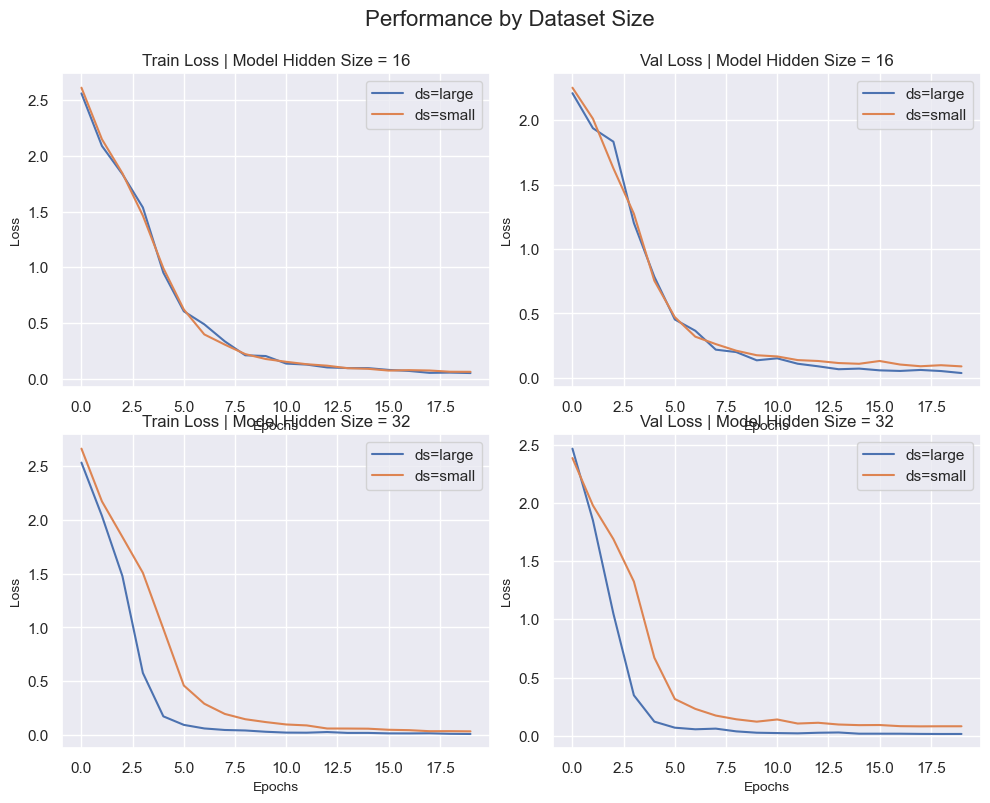

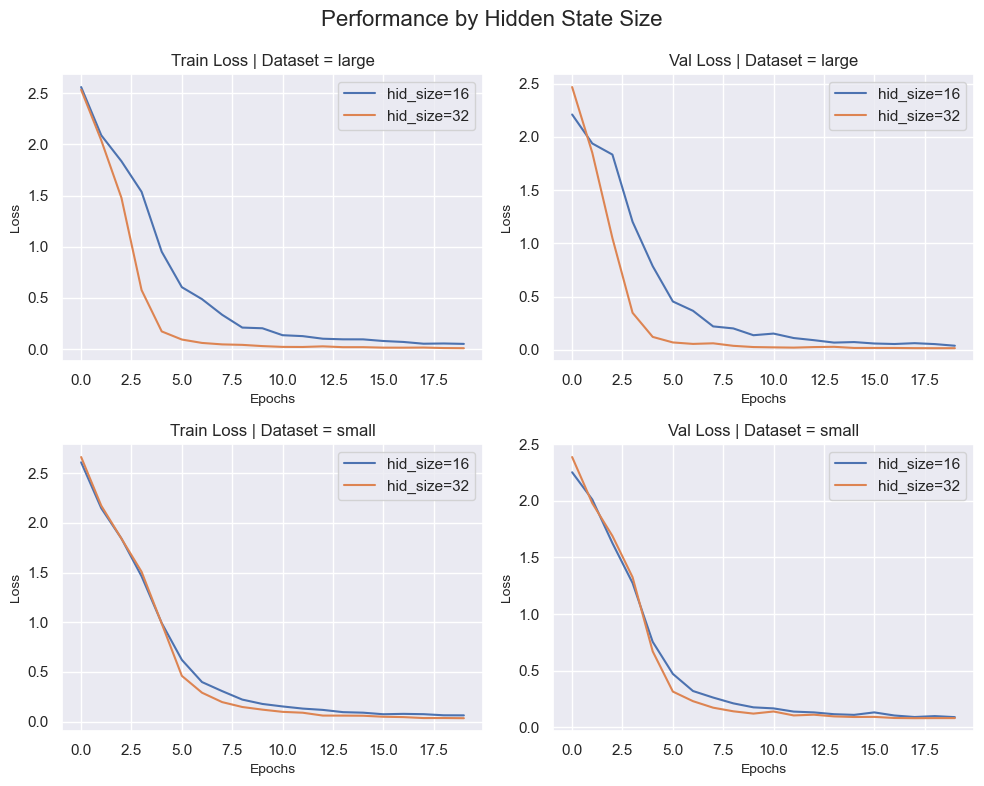

In [ ]:
display(fig1)
display(fig2)

### Step 4: Analyzing results

1. The two graphs paint a similar picture: The larger models perform better, and larger datasets lead to better performance. Could this be due to the difference in mini-batch sizes used for different dataset sizes? 
2. The smaller model doesn't realize the improvements in training loss from the larger dataset as much as the larger models do
3. The larger smaller model performs much better relative to the smaller model on the large dataset than on the small dataset. This is probably because it better utilizes the additional data to learn more complex patterns.

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [23]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, num_layers: int):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size, num_layers=num_layers, vocab_size=vocab_size
        )

    def forward(self, inputs: torch.Tensor):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # pos =
        # x =
        # self_attn = []

        # for block in self.blocks:
        #     ...
        #
        # unormalized_scores =
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []
        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)
        unormalized_scores = self.head(x)

        return unormalized_scores, {"self_attn": self_attn}

In [24]:
decoder_ds_small = DecoderDataset(data_path, "pig_latin_small")
decoder_ds_large = DecoderDataset(data_path, "pig_latin_large")

In [25]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>attacks<EOP>attacksway
Target: attacks<EOP>attacksway<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [26]:
def decoder_generate(
    input: str,
    model: DecoderTransformer,
    dataset: DecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    # idx = TODO
    idx = dataset.to_idx(input)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string


def decoder_translate(
    sentence: str, model: DecoderTransformer, dataset: DecoderDataset
):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [27]:
# model = load_model_auto(
#     DecoderTransformer,
#     vocab_size=len(decoder_ds_small.idx_to_token),
#     hidden_size=16,
#     num_layers=4,
# )
model = DecoderTransformer(
    vocab_size=len(decoder_ds_small.idx_to_token), hidden_size=16, num_layers=4
)

In [28]:
optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=decoder_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 3.083981 | Val loss 1.958903


Epoch 2 | Train loss: 1.759495 | Val loss 1.674273


Epoch 3 | Train loss: 1.551638 | Val loss 1.523412


Epoch 4 | Train loss: 1.394732 | Val loss 1.414328


Epoch 5 | Train loss: 1.281753 | Val loss 1.360562


...

Epoch 47 | Train loss: 0.104624 | Val loss 0.224217


Epoch 48 | Train loss: 0.100682 | Val loss 0.226935


Epoch 49 | Train loss: 0.099131 | Val loss 0.221974


Epoch 50 | Train loss: 0.093716 | Val loss 0.231623


PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/DecoderTransformer/50_epochs/Model_vocab30_hid16_layers4.pt')

In [29]:
decoder_translate("the air conditioning is working", model, decoder_ds_small)

'a-aa-a-aaay-ay-aaaaa aaaaaaaaaaaaaaaaaaaa way-ionagay-aaay-ay- iiiiiiiiiiiiiiiiiiii <SOS><SOS><SOS>--khwhwvkvvvvvrrr'

## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [30]:
# TO DO:


def multihead_scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    # unnorm_attn =
    # masked_unnorm_attn =
    # attention =
    # context =
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [31]:
class MultiheadCausalAttention(Attention):
    proj: nn.Linear

    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        # if self.num_heads > 1:
        #   self.proj = nn.Linear( ,  , bias=False)
        if self.num_heads > 1:
            self.proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, num_heads=num_heads)

    def forward(self, x: torch.Tensor):
        """Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        # B, T, C = x.size()
        # q = self.Q(x).view( ,  ,  ,  ).transpose(1, 2)
        # k = self.K(x).view( ,  ,  ,  ).transpose(1, 2)
        # v = self.V(x).view( ,  ,  ,  ).transpose(1, 2)

        # mask =

        # context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        # reshaped_context =

        # Only perform a projection if the number of heads is more than 1.
        B, T, C = x.size()
        q = self.Q(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        k = self.K(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        v = self.V(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        mask = torch.tril(torch.ones((T, T), device=x.device)).bool()
        context, attention = multihead_scaled_dot_attention(q, k, v, mask)
        reshaped_context = context.transpose(1, 2).contiguous().view(B, T, C)
        if self.num_heads > 1:

            return self.proj(reshaped_context), attention

        else:

            return reshaped_context, attention

In [32]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)
        self.to(device)
        self.filename = model_filename(hidden_size=hidden_size, num_heads=num_heads)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(
        self, vocab_size: int, hidden_size: int, num_layers: int, num_heads: int
    ):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )
        self.to(device)
        self.filename = model_filename(
            hidden_size=hidden_size,
            num_layers=num_layers,
            vocab_size=vocab_size,
            num_heads=num_heads,
        )

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [33]:
def calc_parameters_decoder(model: MultiheadDecoderTransformer) -> int:
    # ------------
    # FILL THIS IN
    # ------------
    # params = TODO # embedding
    # params +=  TODO # QKV linear projections
    # if model.num_heads > 1:
    #   params += TODO # attention linear projection
    # params += TODO # MLP linear
    # params += TODO # layer norms Hint: LayerNorm(x) uses x parameters

    # Hint: Read the code carefully:
    # params += TODO # head
    params = model.vocab_size * model.hidden_size  # embedding
    params += 3 * (model.hidden_size * model.hidden_size)  # QKV linear projections
    if model.num_heads > 1:
        params += model.hidden_size * model.hidden_size  # attention linear projection
    params += 2 * (
        4 * model.hidden_size * model.hidden_size
    )  # MLP linear (2 per block)
    params += 2 * 2 * model.hidden_size  # layer norms (2 per block)

    return params


Training model: hidden_size=16, num_heads=4, num_layers=4


Epoch 1 | Train loss: 2.217859 | Val loss 1.311012


Epoch 2 | Train loss: 0.999941 | Val loss 0.728174


Epoch 3 | Train loss: 0.509989 | Val loss 0.401857


Epoch 4 | Train loss: 0.290280 | Val loss 0.247309


...

Epoch 46 | Train loss: 0.000603 | Val loss 0.009222


Epoch 47 | Train loss: 0.000453 | Val loss 0.009693


Epoch 48 | Train loss: 0.000529 | Val loss 0.009202


Epoch 49 | Train loss: 0.000425 | Val loss 0.009571


Epoch 50 | Train loss: 0.000388 | Val loss 0.009493


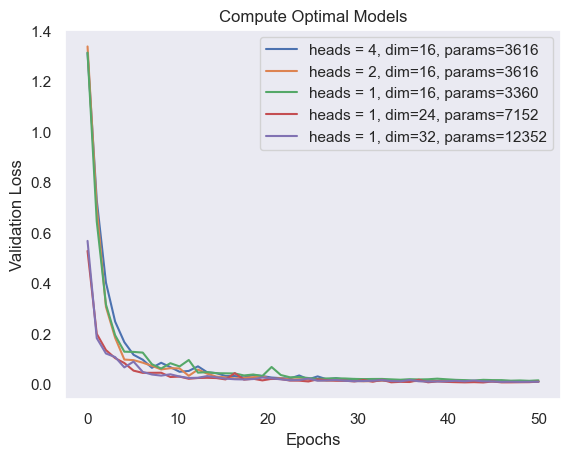

In [34]:
import matplotlib.pyplot as plt
import numpy as np

configs = [
    (16, 4, 4, 64),  # (hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )
    # model = load_model_auto(
    #     MultiheadDecoderTransformer,
    #     vocab_size=len(decoder_ds_large.idx_to_token),
    #     hidden_size=hidden_size,
    #     num_layers=num_layers,
    #     num_heads=num_heads,
    # )
    model = MultiheadDecoderTransformer(
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(model)

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results["val_loss"]), len(results["val_loss"]))
    plt.plot(
        x_points,
        results["val_loss"],
        label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ),
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Compute Optimal Models")
plt.grid()
plt.legend()
plt.show()

In [35]:
plt.clf()

<Figure size 640x480 with 0 Axes>

### Step 4: Analyzing results

It looks like all models trained for 50 epochs converged to a similar validation loss. However, it looks like the model with fewer heads started with much lower training loss and converged faster. Specifically, the 1 head model with 24 or 32 hidden units had the lowest validation loss at each epoch. Notably, the single head 16 hidden unit didn't perform as well, indicating that there is a minimum hidden size required to model the data well (and additionally demonstrated higher variance in training loss).

It would be interesting to see how these models performed on other (more complicated) datasets, and guess at whether the optimal model size would be indicative of the dataset complexity.

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [36]:
from utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params,
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [37]:
from types_hw2 import TrainerHistDict

In [38]:
configs = [
    (40, 2, 4, 256),  # (hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results: dict[int, TrainerHistDict] = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )

    # model = load_model_auto(
    #     MultiheadDecoderTransformer,
    #     vocab_size=len(decoder_ds_large.idx_to_token),
    #     hidden_size=hidden_size,
    #     num_layers=num_layers,
    #     num_heads=num_heads,
    # )
    model = MultiheadDecoderTransformer(
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(model)

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results


Training model: hidden_size=40, num_heads=2, num_layers=4


Epoch 1 | Train loss: 4.759319 | Val loss 1.367960


Epoch 2 | Train loss: 0.846089 | Val loss 0.382018


Epoch 3 | Train loss: 0.258866 | Val loss 0.294434


Epoch 4 | Train loss: 0.134634 | Val loss 0.088001


...

Epoch 46 | Train loss: 0.260807 | Val loss 0.265484


Epoch 47 | Train loss: 0.257847 | Val loss 0.265588


Epoch 48 | Train loss: 0.256842 | Val loss 0.269687


Epoch 49 | Train loss: 0.255257 | Val loss 0.261237


Epoch 50 | Train loss: 0.253043 | Val loss 0.257547


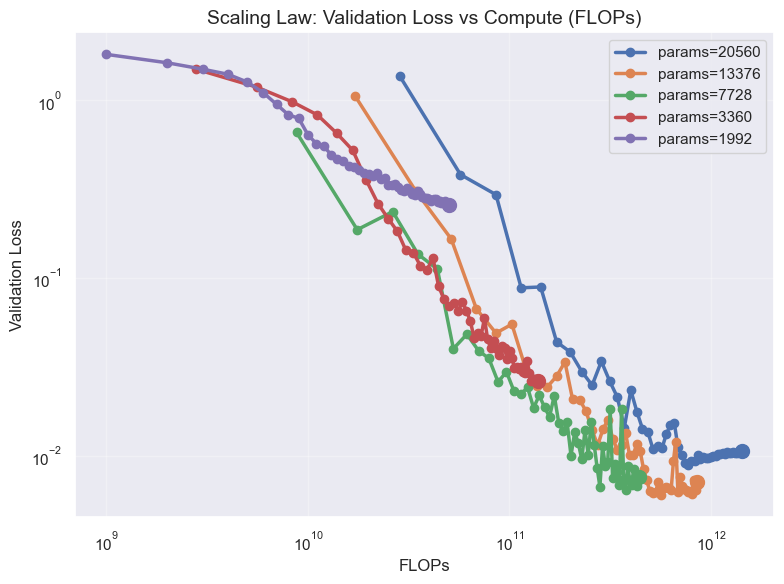

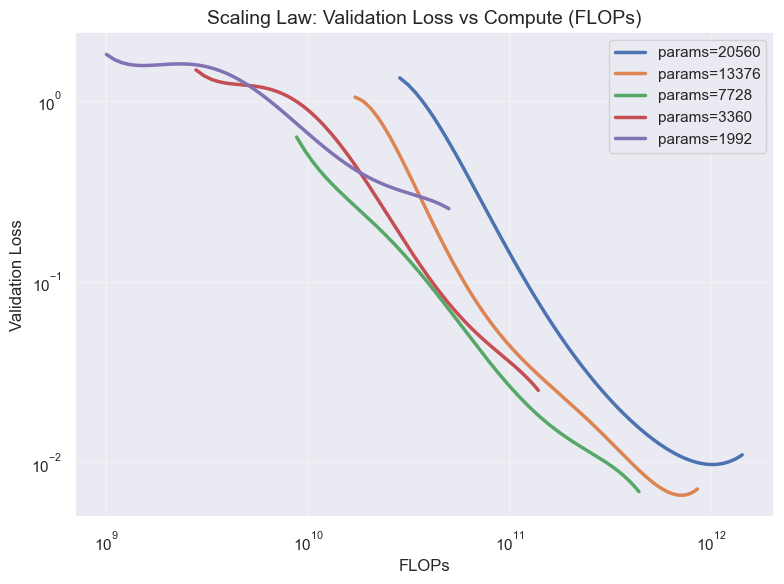

In [39]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [40]:
def find_optim_params(params: torch.Tensor, loss: torch.Tensor):
    x = np.array(params.cpu())
    y = np.array(loss.cpu())

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10 ** (optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00"]
params_vs_loss = []
optimal_params = []

for target in target_flops:
    parameters = []
    val_loss = []

    for params, results in all_results.items():
        loss = interpolate(results["val_loss"], results["flops"], target, deg=4)

        # interpolate returns None if target is out of range
        if loss != None:
            parameters.append(params)
            val_loss.append(loss)

    sorted_indices = torch.argsort(torch.tensor(parameters)).to(device)
    parameters = torch.tensor(parameters).to(device)[sorted_indices]
    val_loss = torch.tensor(val_loss).to(device)[sorted_indices]
    try:
        optimal_params.append(find_optim_params(parameters, val_loss))
        params_vs_loss.append((parameters.tolist(), val_loss.tolist()))
    except Exception as e:
        print(
            f"{optimal_params=}\n\n{params_vs_loss=}\n\n{parameters=}\n\n{val_loss=}\n\n{target=}"
        )

/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_98922/2694499551.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(params.cpu())
/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_98922/2694499551.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(loss.cpu())


8.00 GFlops: Optimal params = 7,633
16.00 GFlops: Optimal params = 4,499
32.00 GFlops: Optimal params = 4,472
64.00 GFlops: Optimal params = 7,435
128.00 GFlops: Optimal params = 9,365


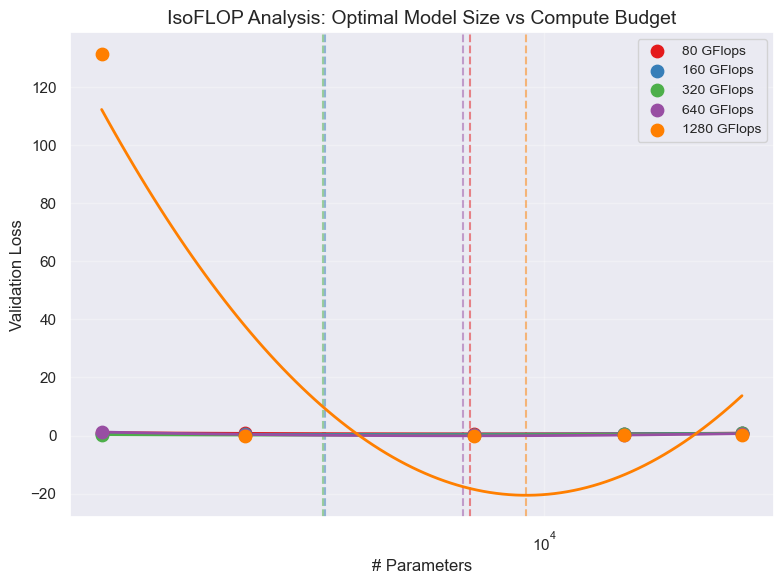

In [41]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

y = 0.1314992772087517x + 2.424400231521431


/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


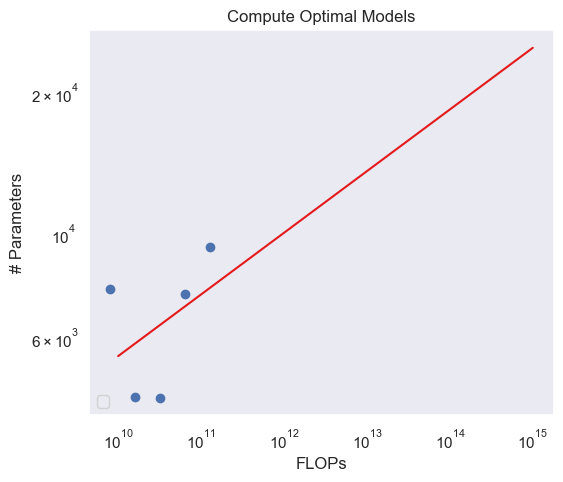

In [ ]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

y = 0.824755800807312x + -2.671545790358438


/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:323: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left")


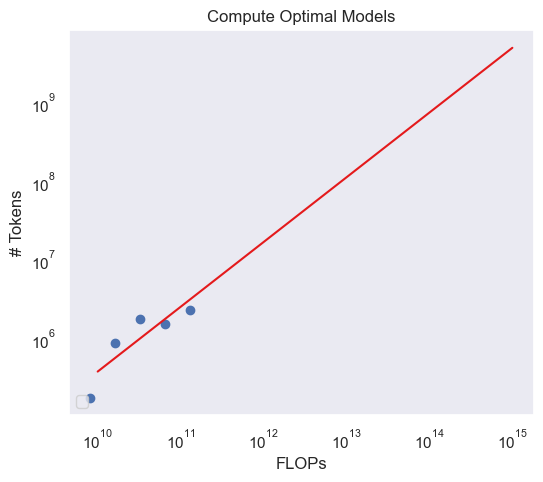

In [43]:
plot_flops_tokens(target_flops, optimal_params, all_results)

### Step 4: Analyzing results

1. Flops vs. # Parameters: It looks like the relationship is quadratic. The graph is hard to interpret because the scale is dominated by the large GFlop values, but it seems like there's a local minimum for the ideal number of parameters for a given compute budget.
2. Flops vs. # Tokens: Unlike the previous graph, this one looks more linear. It seems like the more tokens we have, the better, and there isn't a clear local minima.